In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated
from operator import add
from rich import print


# 1 状態を定義
class OverAllState(TypedDict):
    # ログの型は list[str]。更新方法は上書きではなく add による追記
    logs: Annotated[list[str],add]
    cur_id: str


# 2 ノードを定義
def node_1(state:OverAllState) -> OverAllState:
    pre_id = state["cur_id"]
    return {
        "logs": ["node_1 の実行が完了しました"],
        "cur_id": pre_id + ", node_1"
    }

def node_2(state:OverAllState) -> OverAllState:
    pre_id = state["cur_id"]
    return {
        "logs": ["node_2 の実行が完了しました"],
        "cur_id": pre_id + ", node_2"
    }

# 3 エッジを定義
# 3.1 グラフを作成し、ビルダーを取得
builder = StateGraph( state_schema=OverAllState)
# 3.2 ノードを追加
builder.add_node(node_1)
builder.add_node(node_2)
# 3.3 エッジを追加
builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")
builder.add_edge("node_2",END)

# 4 グラフを取得
graph = builder.compile()

# 5 グラフを実行
result = graph.invoke({"cur_id":"start"})
print(result)


{'logs': ['node_1 の実行が完了しました', 'node_2 の実行が完了しました'], 'cur_id': 'start, node_1, node_2'}

In [2]:
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

---
config:
  flowchart:
    curve: linear
---
graph TD;
        __start__([<p>__start__</p>]):::first
        node_1(node_1)
        node_2(node_2)
        __end__([<p>__end__</p>]):::last
        __start__ --> node_1;
        node_1 --> node_2;
        node_2 --> __end__;
        classDef default fill:#f2f0ff,line-height:1.2
        classDef first fill-opacity:0
        classDef last fill:#bfb6fc

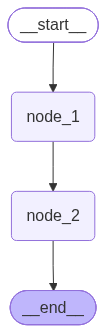

In [3]:
from IPython.display import display, Image

png_bytes = graph.get_graph().draw_mermaid_png()
png = Image(png_bytes)
display(png)

In [ ]:
png_bytes = graph.get_graph().draw_mermaid_png()
print(png_bytes)
png_filename = 'first_demo_graph.png'
with open(png_filename, "wb") as f:
    f.write(png_bytes)

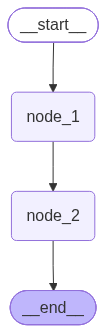

In [5]:
from IPython.display import display

display(graph)